In [21]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
%matplotlib inline

df = pd.read_csv('/content/sample_data/WineQT.csv', sep=';')
df.columns = df.columns.str.strip()
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


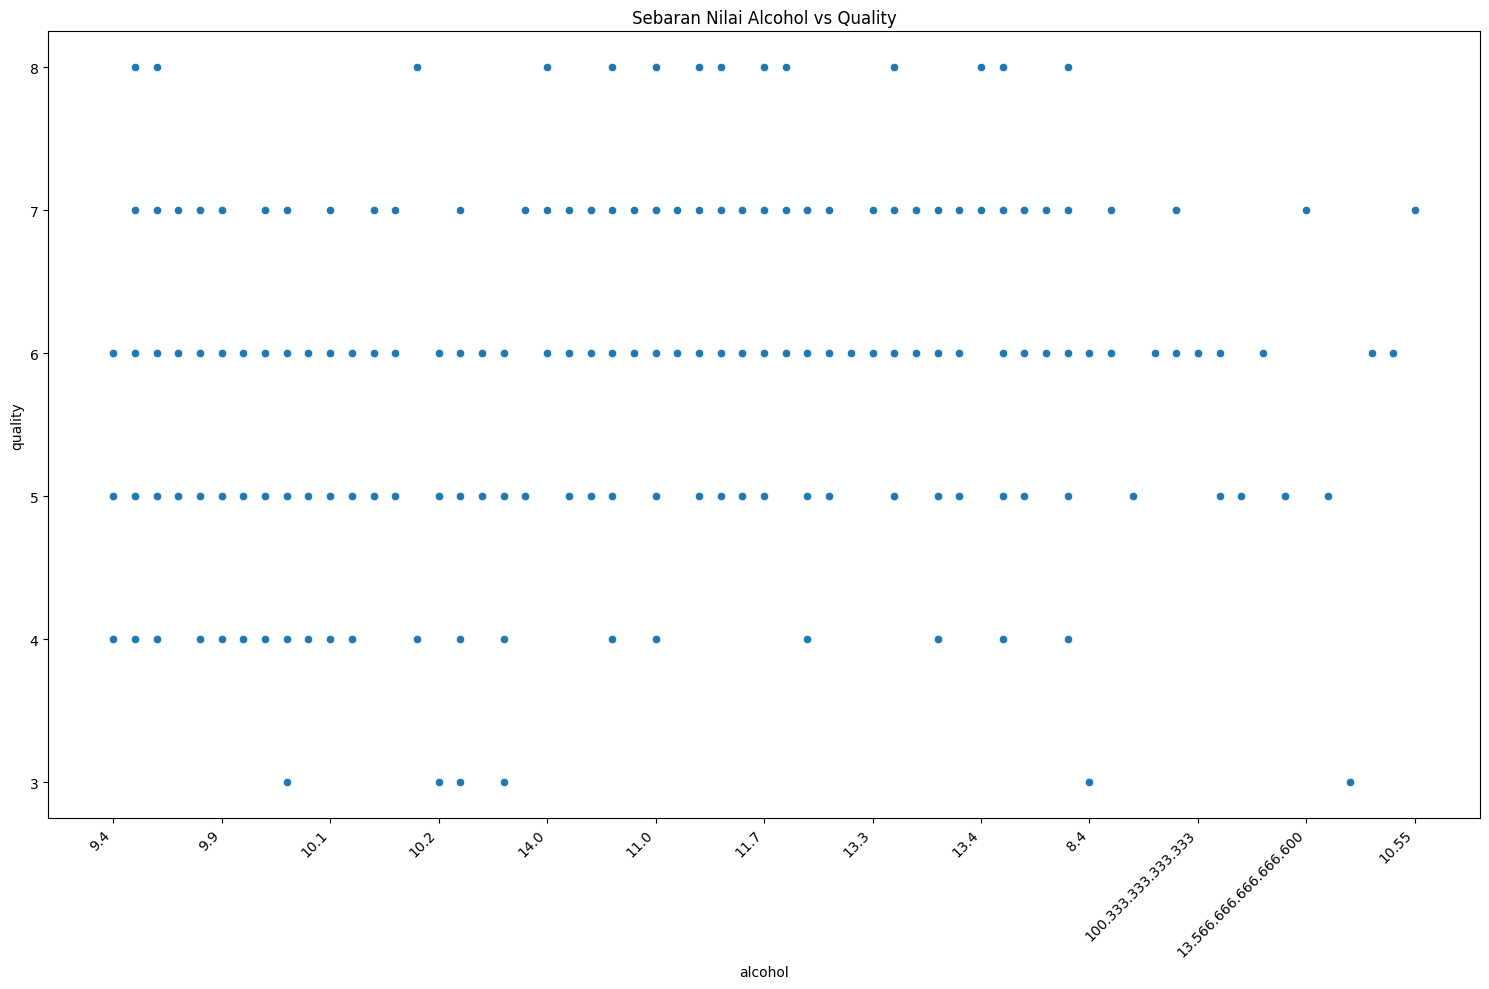

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,pH,sulphates,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,3.311015,0.657708,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.156664,0.170399,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,2.740000,0.330000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,3.205000,0.550000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,3.310000,0.620000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,3.400000,0.730000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,4.010000,2.000000,8.000000,1597.000000


In [22]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality')
plt.title('Sebaran Nilai Alcohol vs Quality')
ax.xaxis.set_major_locator(MaxNLocator(nbins=15))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()
df.describe()

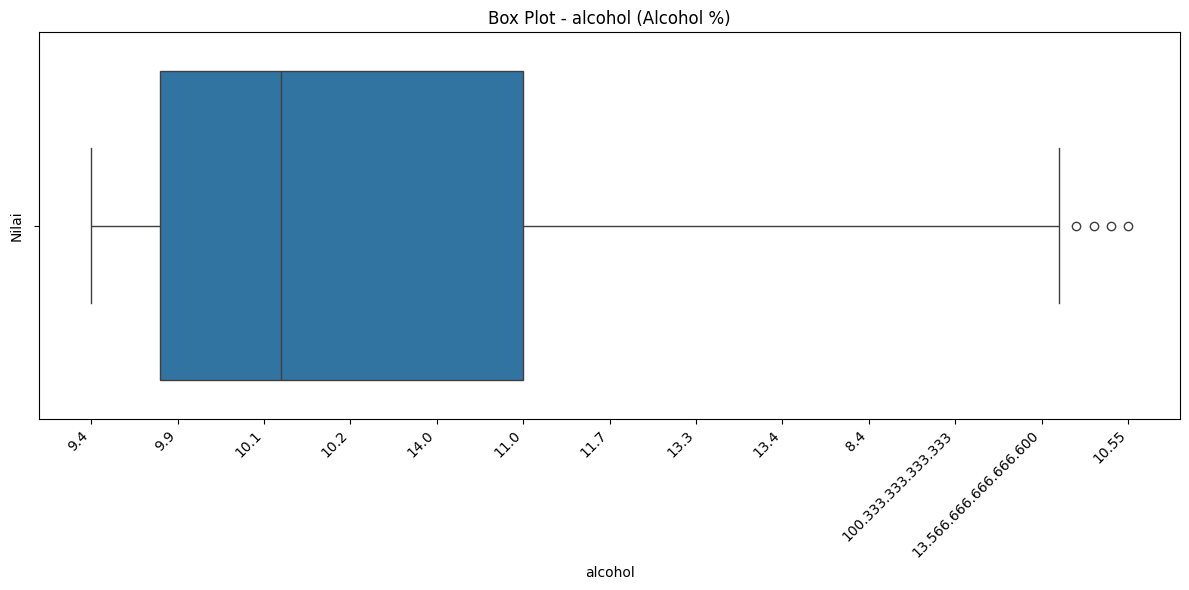

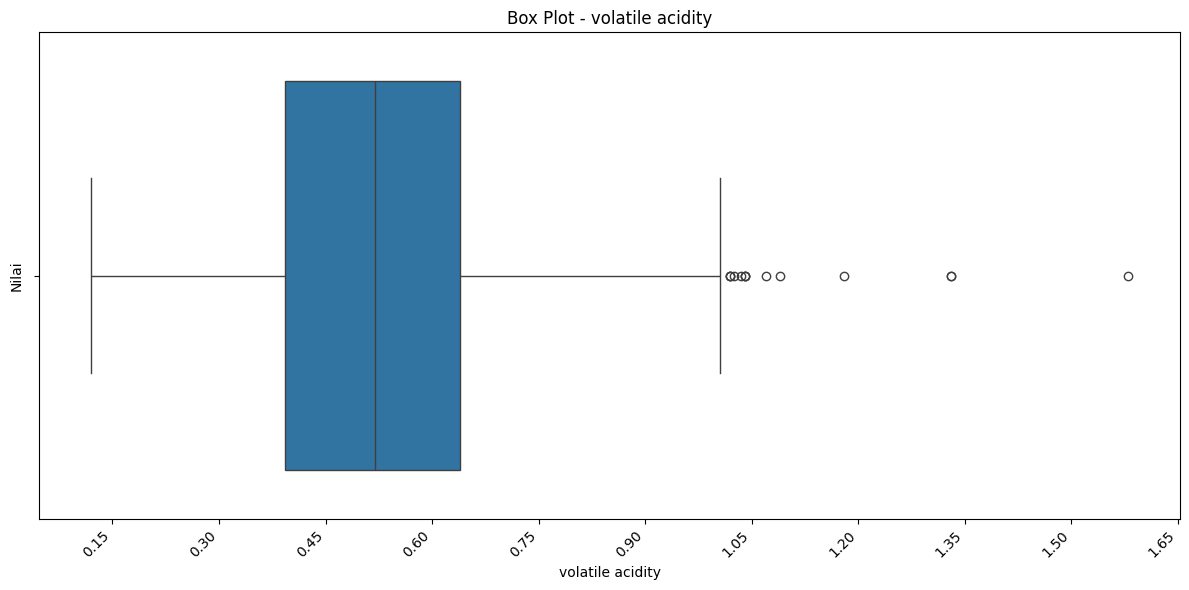

In [23]:
columns = ['alcohol', 'volatile acidity']

for col in columns:
    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col} (Alcohol %)' if col == 'alcohol' else f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    ax.xaxis.set_major_locator(MaxNLocator(nbins=15))
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()

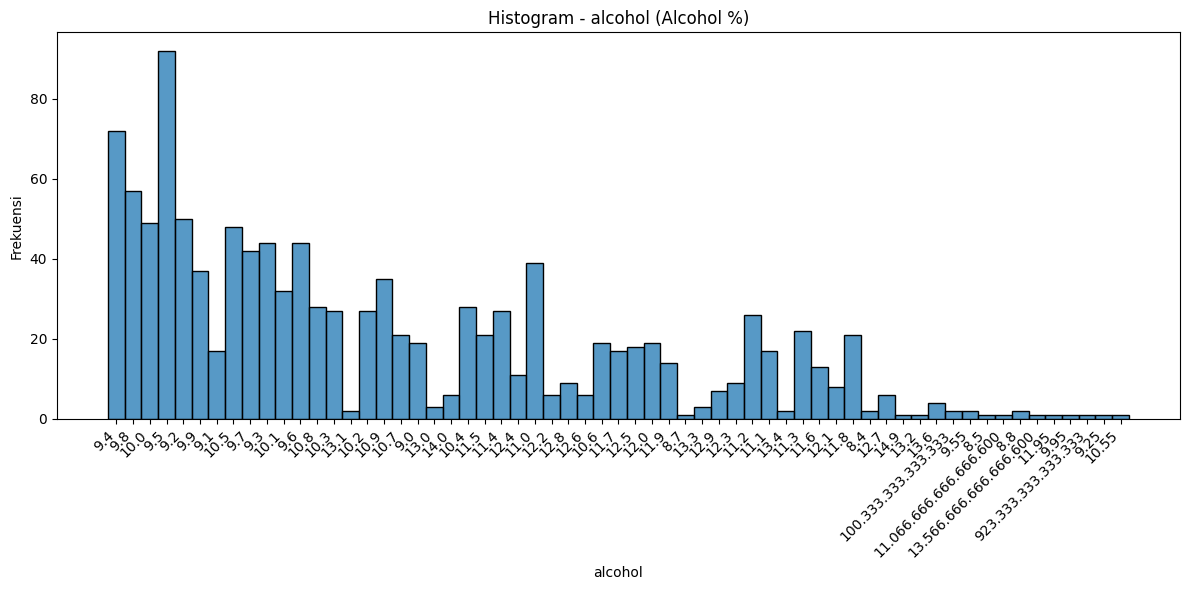

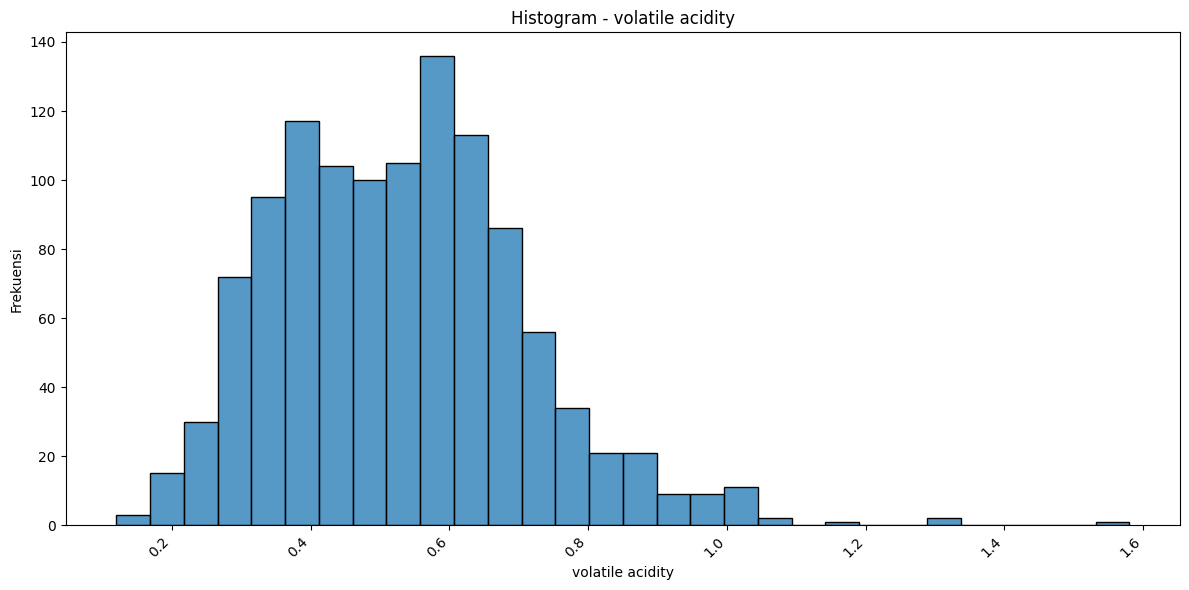

In [24]:
for col in columns:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col} (Alcohol %)' if col == 'alcohol' else f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()

In [25]:
# Drop Duplicates
print(f"Dataframe dimension before duplication drop {df.shape[0]}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


In [26]:
fitur_columns = ['alcohol', 'volatile acidity']
X = df[fitur_columns].values
y = df['quality'].values

In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# The error "ValueError: could not convert string to float: '100.333.333.333.333'"
# indicates that the 'X' array contains non-numeric string values that cannot be
# converted to a float by StandardScaler. This often happens when numerical data
# is imported as strings due to formatting issues (e.g., thousands separators,
# mixed data types in a column, or corrupted entries).

# To fix this, we need to ensure 'X' contains only numerical data (floats).
# We'll convert 'X' to a NumPy array of floats. If any value cannot be converted,
# it will be coerced to NaN (Not a Number). After conversion, we'll handle any
# NaN values (e.g., by filling them with the mean of their respective column).

# Convert X to a DataFrame temporarily for easier numeric conversion and NaN handling
X_df = pd.DataFrame(X, columns=fitur_columns)

# Convert all columns to numeric, coercing errors to NaN
for col in X_df.columns:
    X_df[col] = pd.to_numeric(X_df[col], errors='coerce')

# Handle NaN values: fill with the mean of the column
# (This is a common imputation strategy; other methods might be more suitable
# depending on the data and context, but for a quick fix it's usually acceptable).
for col in X_df.columns:
    if X_df[col].isnull().any():
        X_df[col] = X_df[col].fillna(X_df[col].mean())

# Convert the cleaned DataFrame back to a NumPy array
X_numeric = X_df.values

X_std = StandardScaler().fit_transform(X_numeric) # Use the cleaned X_numeric
df_scalling = pd.DataFrame(data=X_std, columns=fitur_columns)
df_scalling.describe()

,alcohol,volatile acidity
count,1.143000e+03,1.143000e+03
mean,3.232565e-16,4.475860e-16
std,1.000438e+00,1.000438e+00
min,-1.894919e+00,-2.290883e+00
25%,-8.734483e-01,-7.732388e-01
50%,-2.234213e-01,-6.314838e-02
75%,6.123277e-01,6.051720e-01
max,4.141046e+00,5.840349e+00


In [28]:
X_std

array([[-0.96630926,  0.93933222],
       [-0.59486527,  1.94181282],
       [-0.59486527,  1.27349242],
       ...,
       [ 0.05516172,  0.38239855],
       [ 0.70518871,  0.10393172],
       [-0.22342128,  0.6330187 ]])

In [29]:
df_scalling

,alcohol,volatile acidity
0,-0.966309,0.939332
1,-0.594865,1.941813
2,-0.594865,1.273492
3,-0.594865,-1.399789
4,-0.966309,0.939332
...,...,...
1138,0.519467,-0.118842
1139,-0.873448,0.493785
1140,0.055162,0.382399
1141,0.705189,0.103932


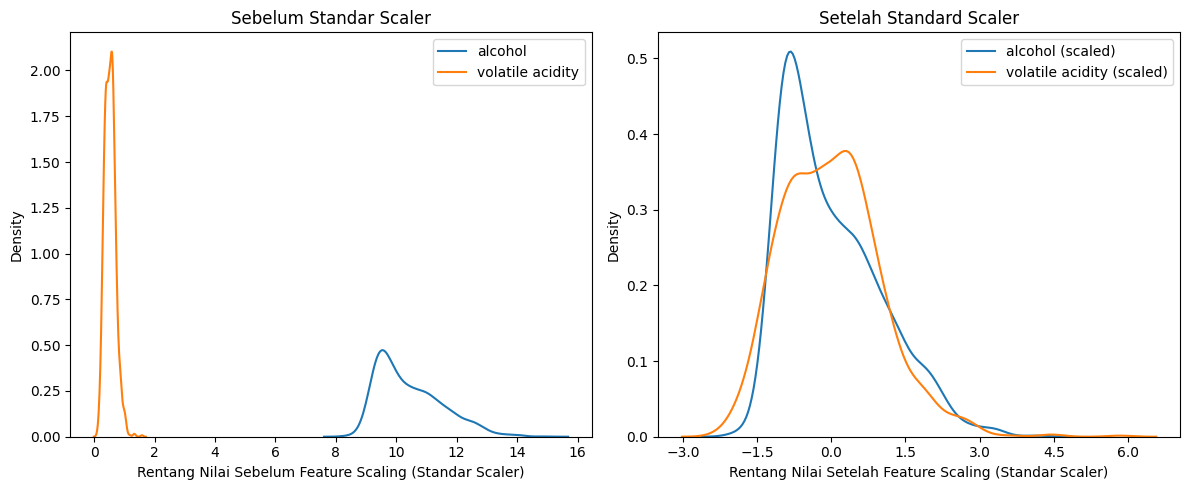

In [30]:
# Cek grafik sebelum dan setelah scaling
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Convert 'alcohol' and 'volatile acidity' in df to numeric, handling errors
# This is necessary because the original df might still have these columns as object/string types,
# causing the TypeError in sns.kdeplot.
df['alcohol'] = pd.to_numeric(df['alcohol'], errors='coerce')
df['volatile acidity'] = pd.to_numeric(df['volatile acidity'], errors='coerce')

# Fill any NaN values that resulted from coercion (e.g., if there were actual non-numeric strings)
# For simplicity, filling with the mean, but other imputation strategies could be used.
df['alcohol'].fillna(df['alcohol'].mean(), inplace=True)
df['volatile acidity'].fillna(df['volatile acidity'].mean(), inplace=True)

ax1.set_title('Sebelum Standar Scaler')
sns.kdeplot(data=df, x='alcohol', ax=ax1, label='alcohol')
sns.kdeplot(data=df, x='volatile acidity', ax=ax1, label='volatile acidity')

ax2.set_title('Setelah Standard Scaler')
sns.kdeplot(data=df_scalling, x='alcohol', ax=ax2, label='alcohol (scaled)')
sns.kdeplot(data=df_scalling, x='volatile acidity', ax=ax2, label='volatile acidity (scaled)')

ax1.set_xlabel('Rentang Nilai Sebelum Feature Scaling (Standar Scaler)')
ax2.set_xlabel('Rentang Nilai Setelah Feature Scaling (Standar Scaler)')

ax1.xaxis.set_major_locator(MaxNLocator(nbins=10))
ax2.xaxis.set_major_locator(MaxNLocator(nbins=10))

ax1.legend()
ax2.legend()

plt.tight_layout()
plt.show()

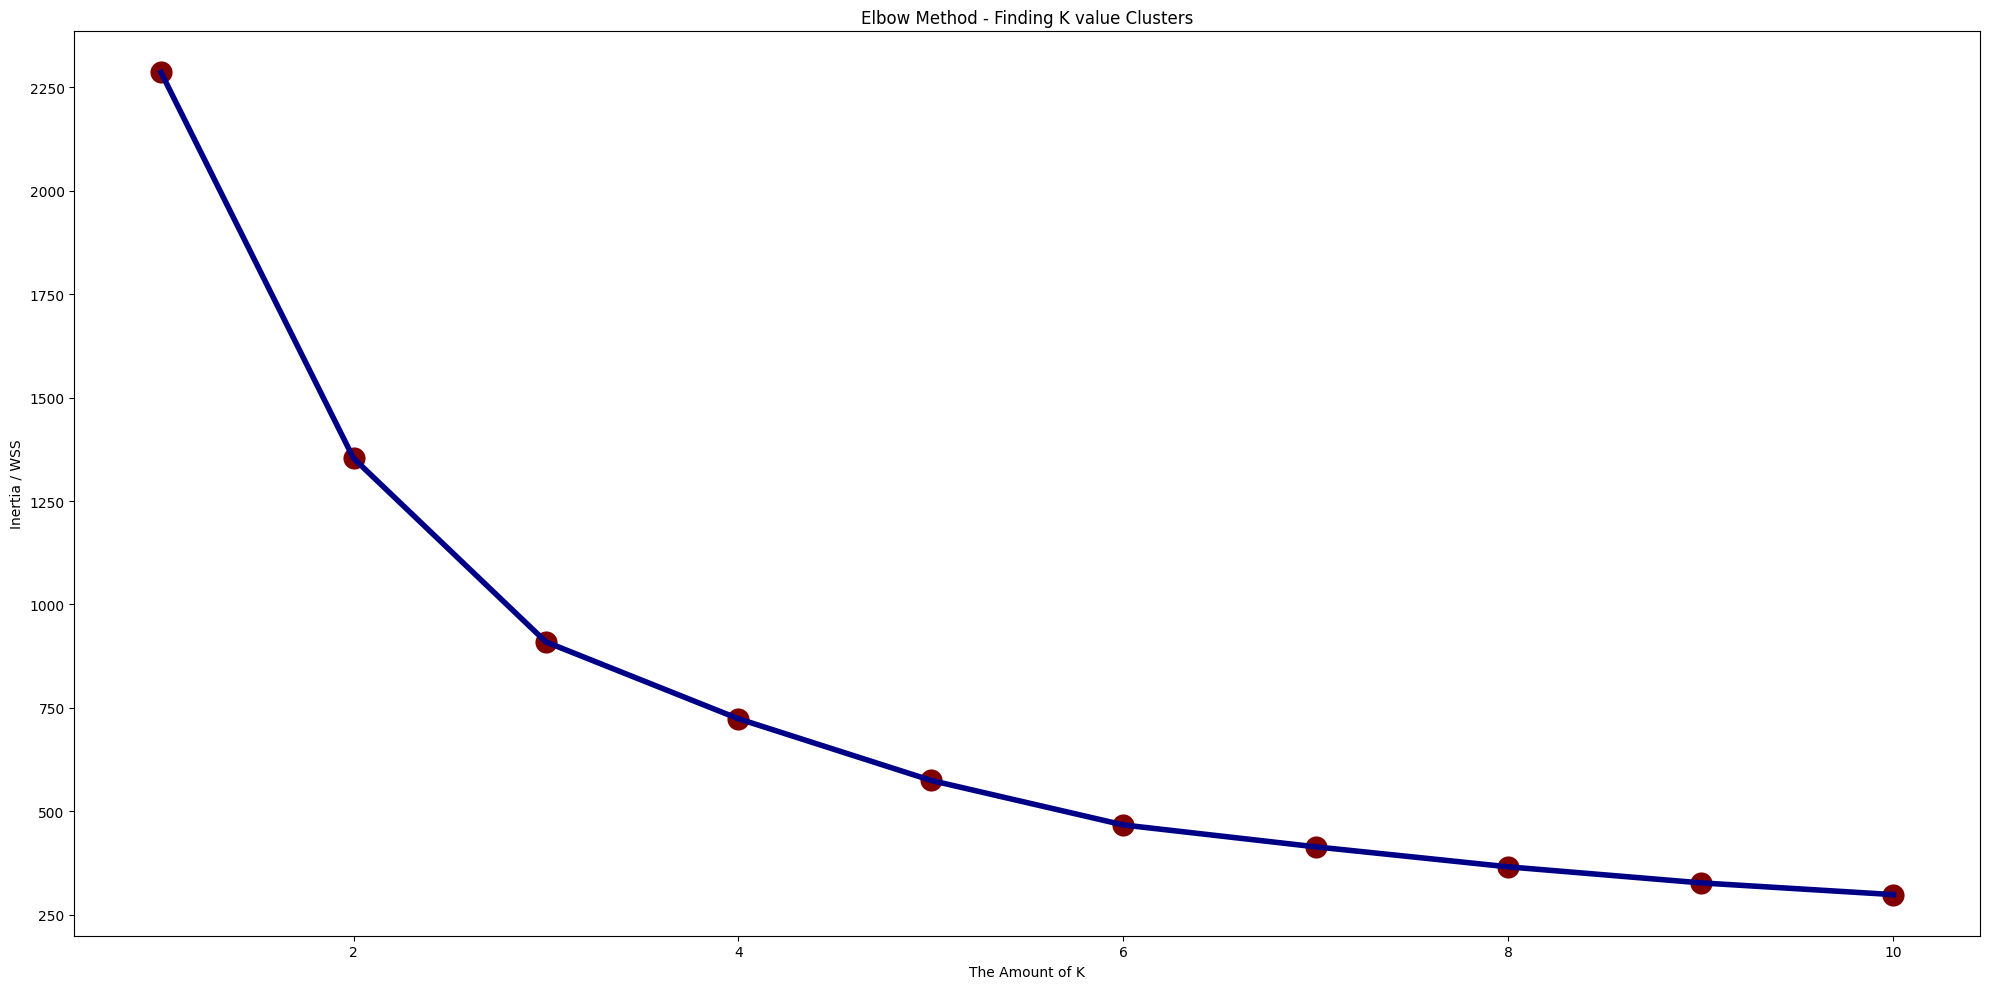

In [31]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init=10)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))
sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth=4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Inertia / WSS')
plt.tight_layout()
plt.show()

In [32]:
# Dari hasil diatas elbow nya dipilih pada angka 3,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=0, n_init=10)
kmeans_elbow.fit(df_scalling.values)

df['cluster_elbow'] = kmeans_elbow.labels_
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5,2,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6,3,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,2
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.9949,3.45,0.58,10.5,5,1594,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.9951200000000001,3.52,0.76,11.2,6,1595,2


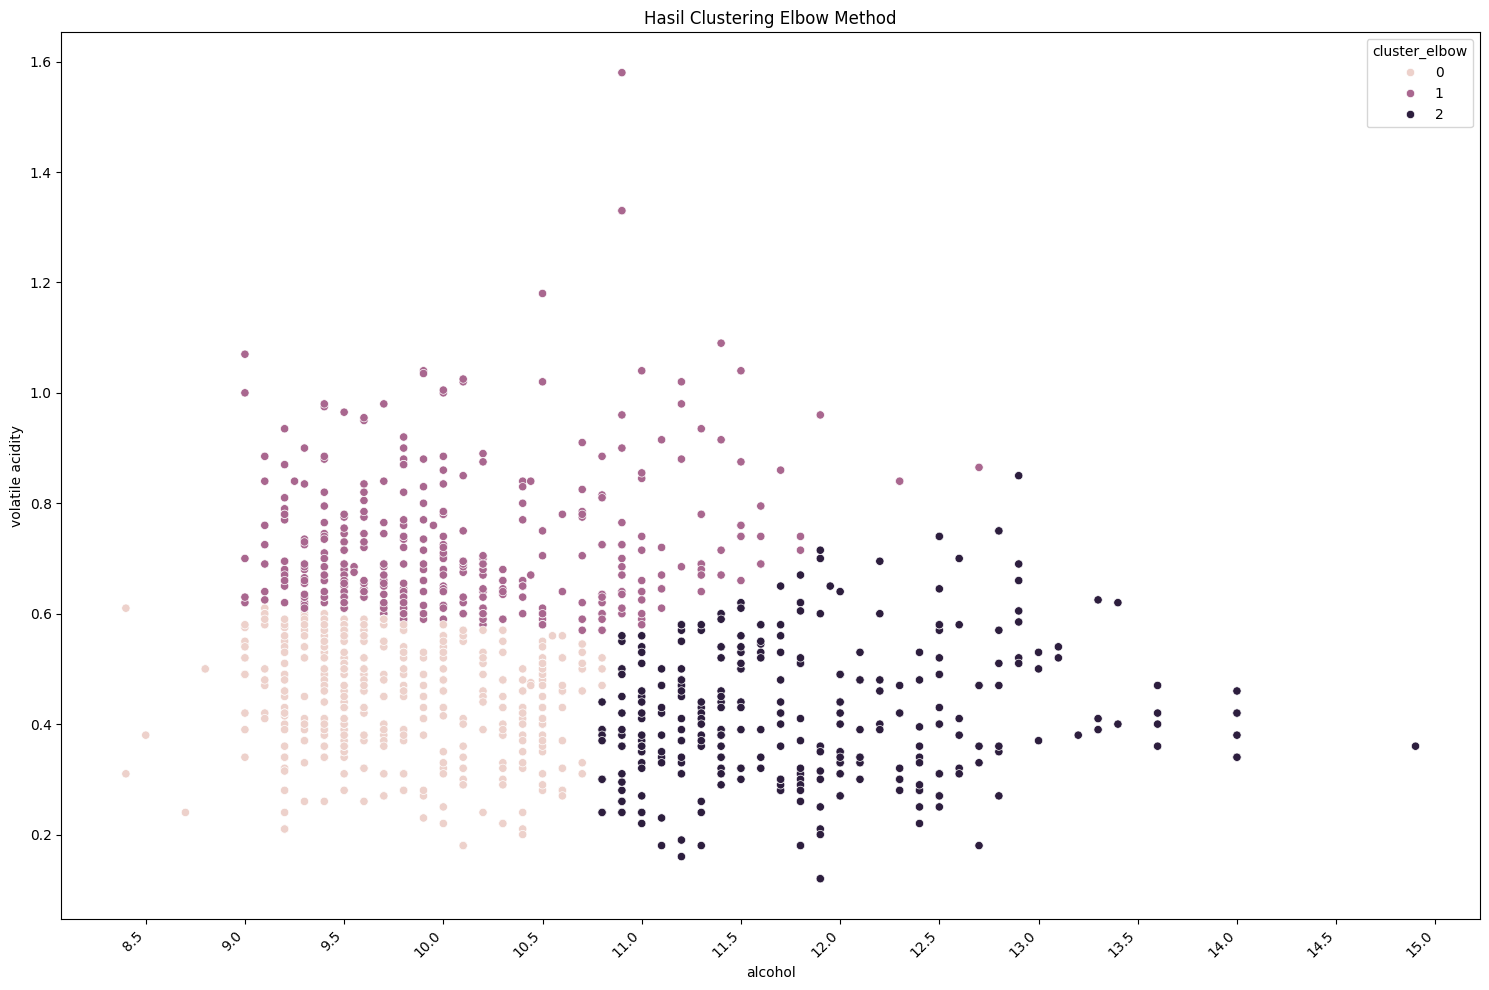

In [33]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='volatile acidity', hue='cluster_elbow')
plt.title('Hasil Clustering Elbow Method')
ax.xaxis.set_major_locator(MaxNLocator(nbins=15))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

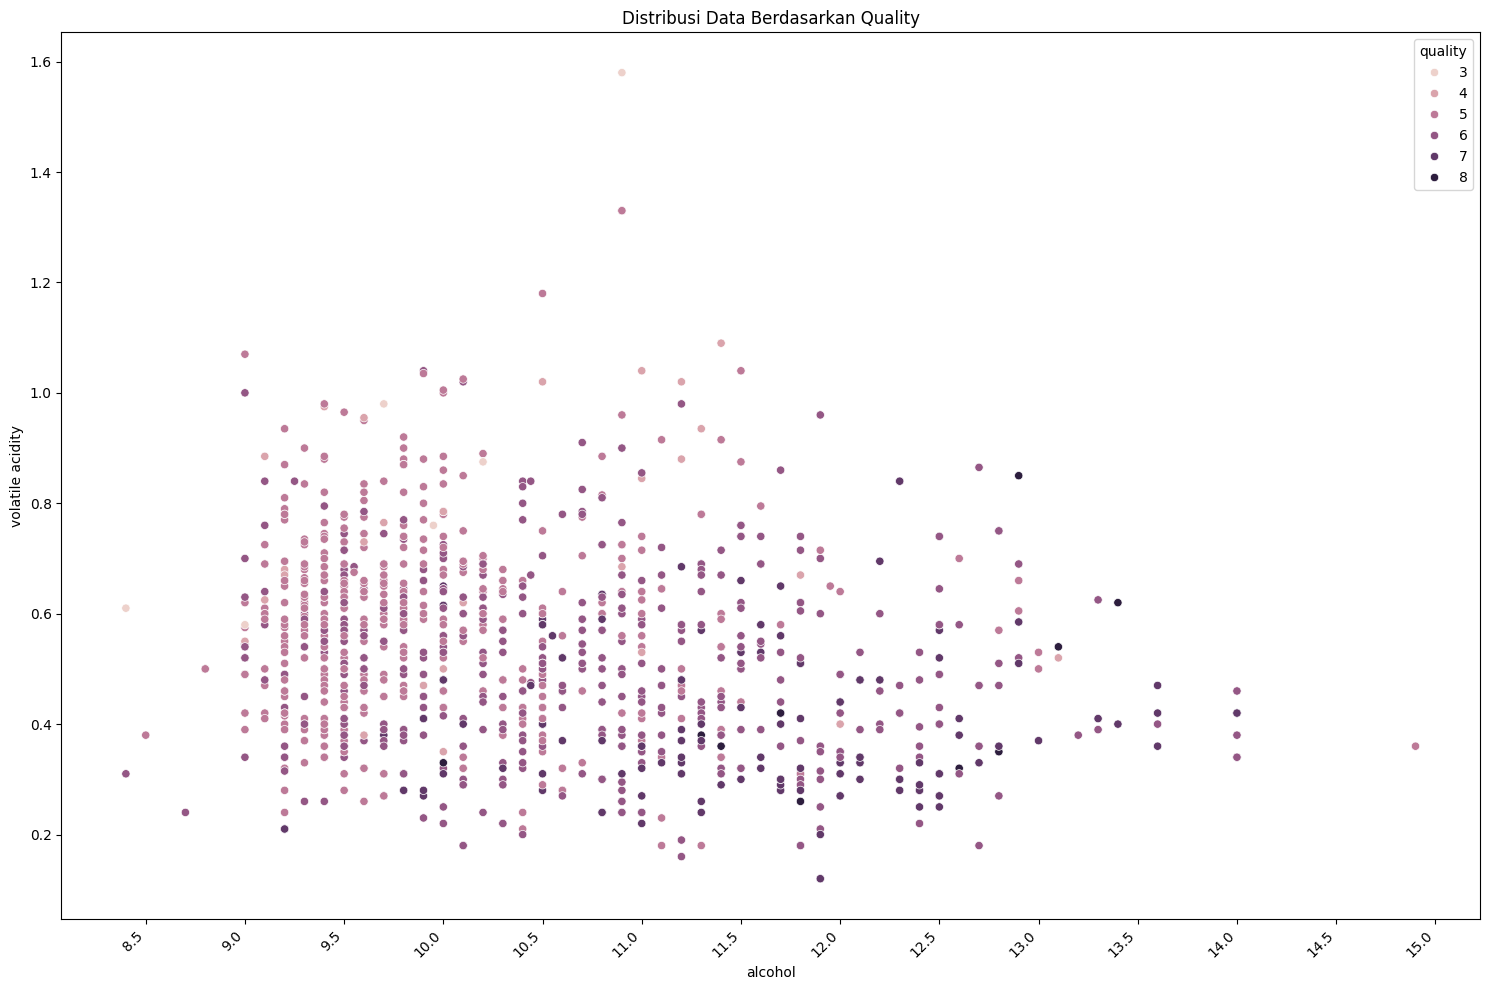

In [34]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='volatile acidity', hue='quality')
plt.title('Distribusi Data Berdasarkan Quality')
ax.xaxis.set_major_locator(MaxNLocator(nbins=15))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

In [35]:
!pip install yellowbrick

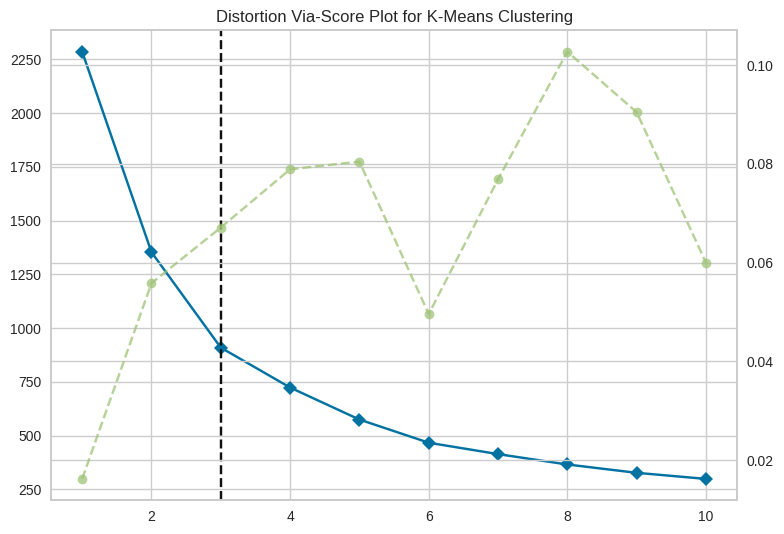

In [36]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

k_means_via = KMeans(random_state=0, n_init=10)
visualizer = KElbowVisualizer(k_means_via, k=(1, 11), timings=True)
visualizer.fit(df_scalling.values)
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.tight_layout()
plt.show()

In [37]:
# Dari hasil diatas K-nya dipilih berdasarkan titik distorsi optimal
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0, n_init=10)
kmeans_via.fit(df_scalling.values)

df['cluster_via'] = kmeans_via.labels_
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5,2,1,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6,3,0,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,2,2
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.9949,3.45,0.58,10.5,5,1594,1,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.9951200000000001,3.52,0.76,11.2,6,1595,2,2


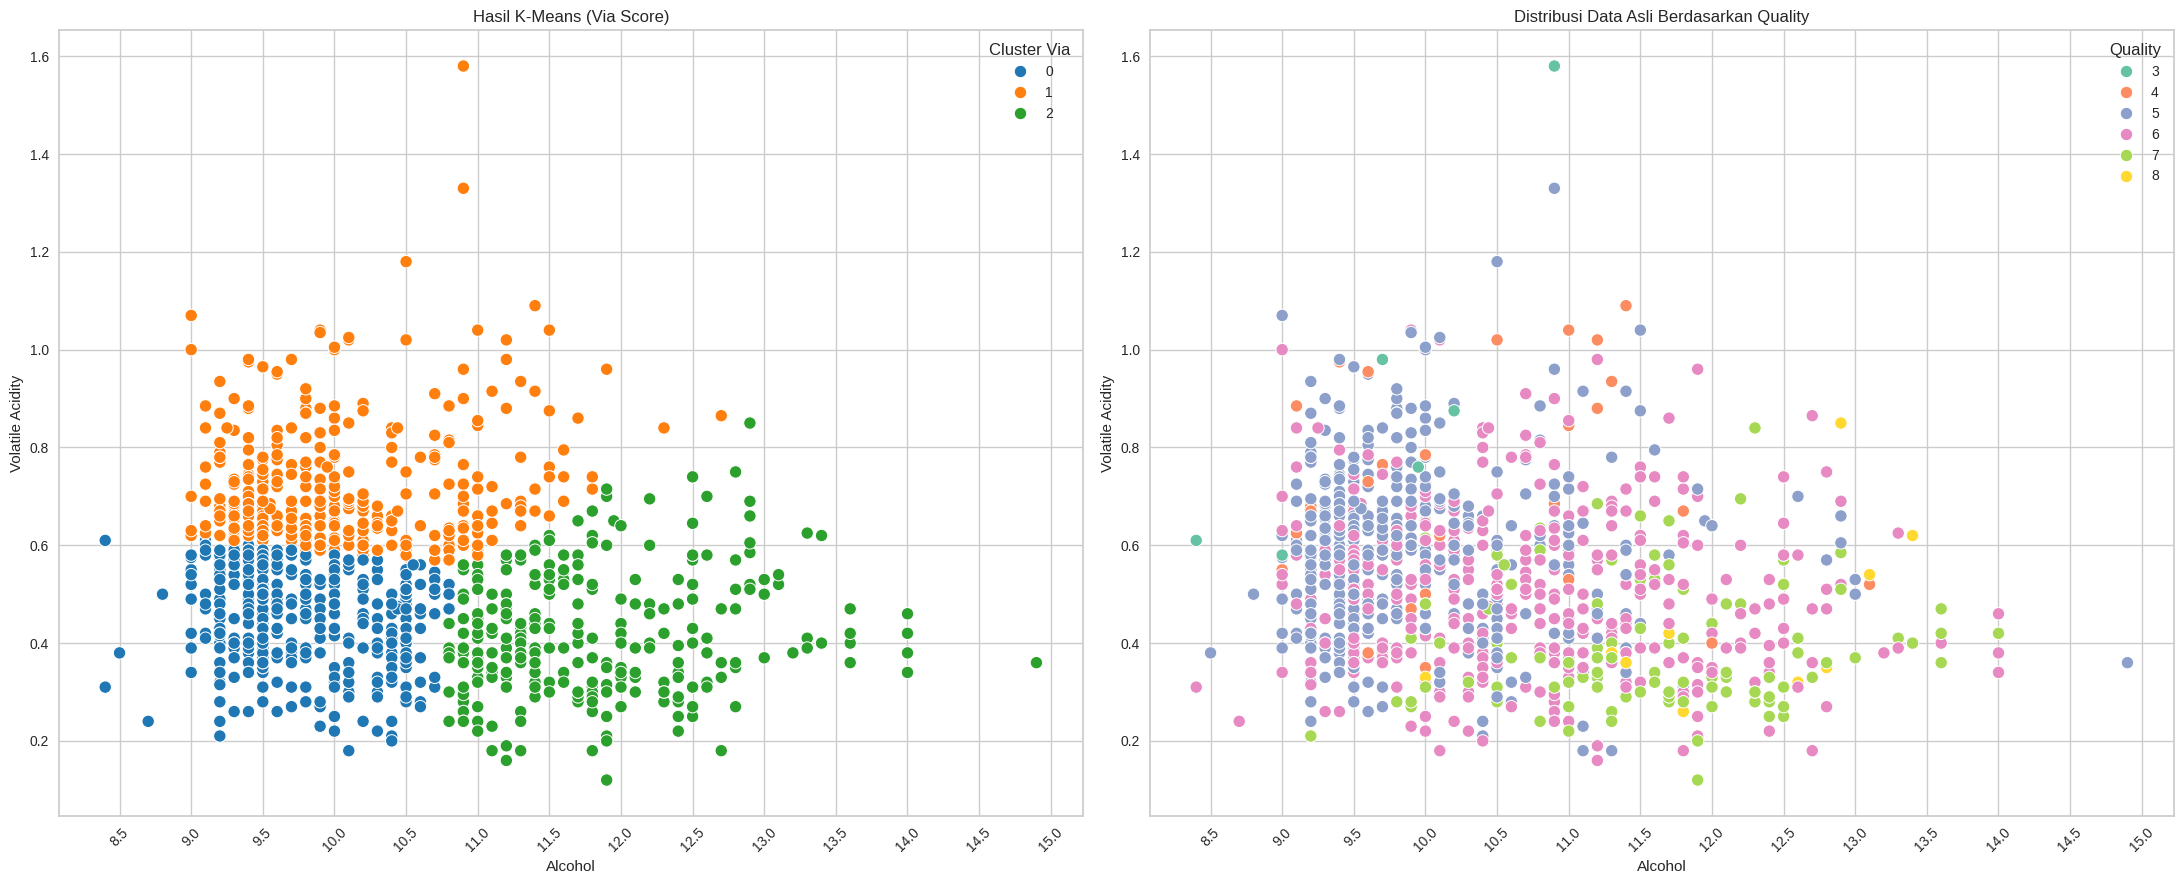

In [38]:
# Evaluasi dan perbandingan hasil cluster dengan distribusi data asli
fig, axes = plt.subplots(ncols=2, figsize=(22, 9))

sns.scatterplot(
    data=df,
    x='alcohol',
    y='volatile acidity',
    hue='cluster_via',
    palette='tab10',
    s=80,
    ax=axes[0]
)
axes[0].set_title('Hasil K-Means (Via Score)')
axes[0].set_xlabel('Alcohol')
axes[0].set_ylabel('Volatile Acidity')
axes[0].legend(title='Cluster Via', loc='best')
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=15))
axes[0].tick_params(axis='x', rotation=45, labelsize=10)

sns.scatterplot(
    data=df,
    x='alcohol',
    y='volatile acidity',
    hue='quality',
    palette='Set2',
    s=80,
    ax=axes[1]
)
axes[1].set_title('Distribusi Data Asli Berdasarkan Quality')
axes[1].set_xlabel('Alcohol')
axes[1].set_ylabel('Volatile Acidity')
axes[1].legend(title='Quality', loc='best')
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=15))
axes[1].tick_params(axis='x', rotation=45, labelsize=10)

plt.tight_layout()
plt.show()

quality      3   4    5    6    7   8
cluster_via                          
0            2   7  217  188   27   2
1            4  21  228  118   13   0
2            0   5   38  156  103  14


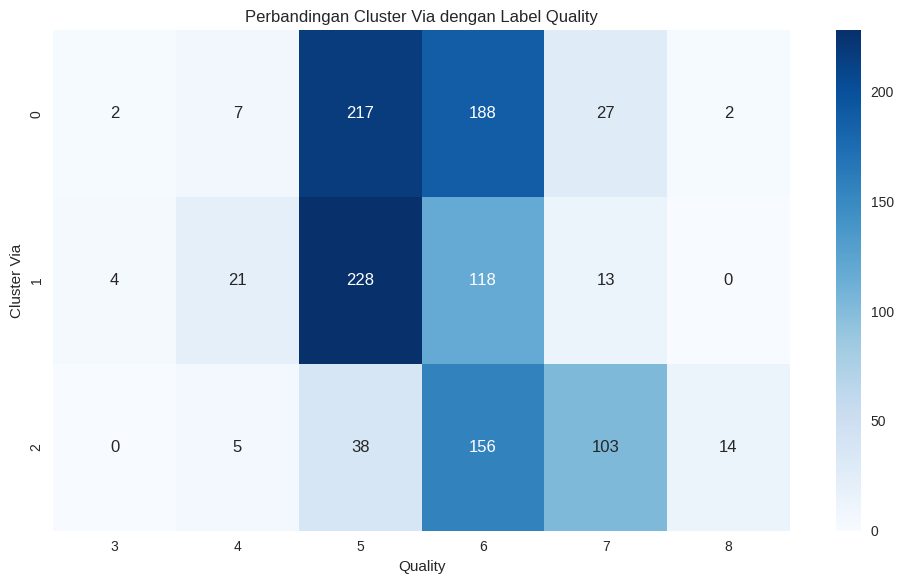

In [39]:
# Bandingkan dengan label quality
ct = pd.crosstab(df['cluster_via'], df['quality'])
print(ct)

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Perbandingan Cluster Via dengan Label Quality')
plt.ylabel('Cluster Via')
plt.xlabel('Quality')
plt.tight_layout()
plt.show()